# Massive production of cancer synthetic RNA-Seq Gene Expression Samples - Tester

This jupyter presents the code for testing the WGAN-GP for producing synthetic samples related to a given cohort.

In [1]:
import time
import torch
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import cuda,FloatTensor
from torch.nn import Sequential,Linear,LeakyReLU, BatchNorm1d, Module,Tanh ## Clases de redes neuronales
from torch.utils.data import DataLoader,Dataset,random_split
from torch.autograd import Variable, grad
from torch.optim import Adam, RMSprop

from scipy.stats import ks_2samp


import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler


In [2]:
#Checking available devices
print(cuda.device_count())
print(cuda.get_device_name(0))

1
NVIDIA GeForce MX350


In [3]:
class Generator(Module):

    def __init__(self, z_length = 10, output_size: int = None) -> None:
        super(Generator,self).__init__()
        
        self.model = Sequential(
            Linear(z_length,32),
            LeakyReLU(0.2, inplace=True),

            Linear(32,64),
            BatchNorm1d(64,0.8),
            LeakyReLU(0.2, inplace=True),

            Linear(64,output_size),
            BatchNorm1d(output_size,0.8),
            Tanh()
        )

    def forward(self, z):
        return self.model(z)


## Loading data and creating dataloaders

In [4]:
#Loading expression matrix
cohort = "PRAD" #Options: BRCA, LUAD, PRAD, THCA
exp_matrix = pd.read_csv(f'../data/{cohort}/tumor_exp_matrix.csv',sep=';')

exp_matrix = np.array(exp_matrix.values)
scaler_exp_matrix = StandardScaler().fit(exp_matrix)
scaled_exp_matrix = scaler_exp_matrix.transform(exp_matrix)

In [5]:
#Preparing data for clipping
min_values = exp_matrix.min(axis=0)
max_values = exp_matrix.max(axis=0)

std_values = np.sqrt(scaler_exp_matrix.var_)

## Initialising model

In [6]:
# Initialize generator and discriminator
generator = Generator(output_size=exp_matrix.shape[1])

if cuda:
    generator.cuda()

In [7]:
#Loading generator from model
generator.load_state_dict(torch.load(f'./models/generator_{cohort}.mdl'))

<All keys matched successfully>

# Generating Samples by the trained network

In [8]:
def generate_samples(n: int = None):
    generator.eval()
    z = Variable(torch.Tensor(np.random.normal(0, 1, (n, 10)))).cuda()
    fake_samples = generator(z)
    return fake_samples

synthetic_samples = pd.DataFrame(generate_samples(exp_matrix.shape[0]).cpu().data.numpy())

In [9]:
restituted_synth_matrix = pd.DataFrame(scaler_exp_matrix.inverse_transform(synthetic_samples.values))

restituted_synth_matrix = pd.DataFrame(np.clip(restituted_synth_matrix,
                                               a_min=min_values,
                                               a_max=max_values))
restituted_synth_matrix

,0,1,2,3,4,5,6,7,8,9,...,84,85,86,87,88,89,90,91,92,93
0,10.748489,11.893179,6.701931,9.920286,5.301637,10.791668,1.964404,10.971972,12.516094,11.658651,...,10.336152,6.234562,12.353132,11.929219,14.706680,10.520326,11.442863,10.305772,9.539515,9.945264
1,10.743343,12.313251,5.125334,9.561460,5.302114,10.792101,1.704215,11.464758,12.514182,11.656828,...,10.248861,5.984484,12.340775,12.003455,14.706419,10.520964,11.446898,10.324122,9.549106,9.940557
2,11.945018,11.856175,7.055534,9.318525,1.880608,11.700369,2.021243,8.576571,10.834676,12.733511,...,11.415409,6.501654,13.317491,12.723403,17.227369,10.518380,12.055012,10.381818,10.551745,7.643272
3,10.749553,13.058339,5.505612,9.429235,5.302239,10.793368,0.000000,11.571257,12.516969,11.686732,...,10.280618,5.951729,12.570381,12.248298,14.706549,11.288606,11.504665,10.924837,9.571238,9.951518
4,12.169609,11.640270,7.090724,9.894131,1.877378,11.012099,1.035126,8.462835,10.801995,11.658504,...,11.691760,7.044262,12.542627,11.922013,15.842111,10.522219,11.463860,10.314398,9.547997,7.525275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,12.174514,11.643897,7.120538,9.786345,1.877426,11.334314,2.021319,8.463103,10.802222,12.753632,...,11.692494,6.788772,13.352173,11.874984,16.898390,11.644772,11.472439,10.337848,10.631926,7.544719
494,11.606515,13.018322,6.924366,9.723866,4.006449,12.256479,1.904876,11.185960,11.257056,12.818046,...,10.867742,7.189608,12.878399,13.120334,17.181715,10.656041,13.071074,11.606820,10.685926,7.600826
495,11.597548,12.611756,7.111062,6.728071,1.887736,10.830448,1.984973,8.941370,12.508460,12.793572,...,10.535853,7.228822,13.040257,13.309585,16.172028,11.856972,13.117605,10.178149,10.306887,8.879012
496,12.147676,13.092093,4.799711,9.323970,5.292426,12.282071,0.000000,11.571434,12.511486,12.829601,...,11.672122,5.403617,13.358102,13.415066,17.240589,11.851838,13.107751,11.647635,10.821101,9.944178


## Uniform Maniforld Approximation and Projection (UMAP) results

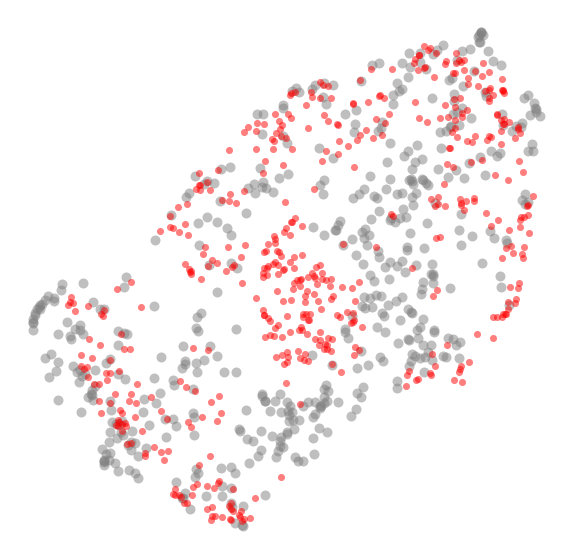

In [10]:
reducer = umap.UMAP(random_state=100)

combined_data = np.concatenate((scaled_exp_matrix,synthetic_samples.values))
emb_2d = reducer.fit_transform(combined_data)

cmap = plt.cm.jet

x_1 = [el[0] for el in emb_2d[:scaled_exp_matrix.shape[0]]]
y_1 = [el[1] for el in emb_2d[:scaled_exp_matrix.shape[0]]]

plt.figure(figsize=(10, 10))
plt.scatter(x_1,y_1,alpha=0.5, c = 'gray', s=100, lw = 0, label='Real')


x_2 = [el[0] for el in emb_2d[scaled_exp_matrix.shape[0]:]]
y_2 = [el[1] for el in emb_2d[scaled_exp_matrix.shape[0]:]]
plt.scatter(x_2,y_2, alpha=0.5, c='red', s=50, lw = 0, label='Fake')

plt.axis('off')
plt.savefig(f'../../plots/{cohort}-umap.pdf',dpi = 300, format='pdf', bbox_inches="tight")

In [11]:
#KL divergence - Two distributions
# Create 2D histograms for the distributions
hist_dist1,x_edges, y_edges = np.histogram2d(x_1, y_1, bins=20, density=True)
hist_dist2, _, _ = np.histogram2d(x_2, y_2, bins=(x_edges, y_edges), density=True)

# Normalize histograms
hist_dist1 /= np.sum(hist_dist1)
hist_dist2 /= np.sum(hist_dist2)

hist_dist1 = hist_dist1.flatten() 
hist_dist2 = hist_dist2.flatten()

In [12]:
print(ks_2samp(y_1,y_2))
print(ks_2samp(x_1,x_2))

KstestResult(statistic=0.13253012048192772, pvalue=0.00031254131315144054)
KstestResult(statistic=0.0963855421686747, pvalue=0.019528383703763252)


In [13]:
def calculate_bhatt_distance(pdf1,pdf2):
    # Calculate Bhattacharyya coefficient
    bc = np.sum(np.sqrt(pdf1 * pdf2))

    # Calculate Bhattacharyya distance
    bd = -np.log(bc)
    return bd

In [14]:
# Calculate Bhattacharyya distance
bhatt_dist = calculate_bhatt_distance(hist_dist1,hist_dist2)
print(f"Bhattacharyya Distance = {bhatt_dist}")

Bhattacharyya Distance = 0.6250841531199629


## Principal component analysis (PCA) Results

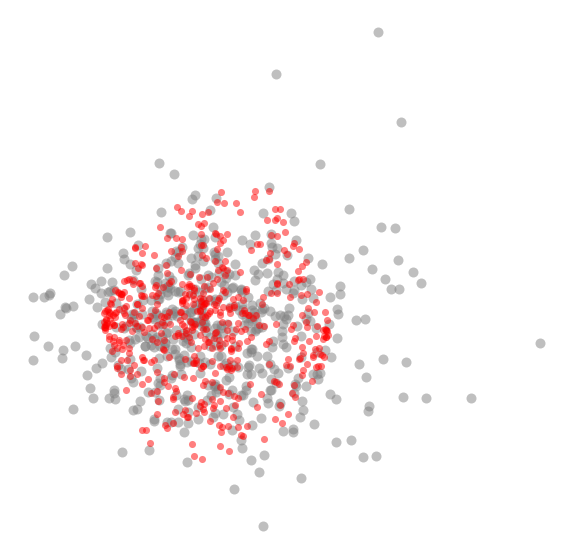

In [15]:
from sklearn.decomposition import PCA

reducer = PCA(n_components=2, random_state=0)

combined_data = np.concatenate((scaled_exp_matrix,synthetic_samples.values))
emb_2d = reducer.fit_transform(combined_data)

cmap = plt.cm.jet

x_1 = [el[0] for el in emb_2d[:scaled_exp_matrix.shape[0]]]
y_1 = [el[1] for el in emb_2d[:scaled_exp_matrix.shape[0]]]

plt.figure(figsize=(10, 10))
plt.scatter(x_1,y_1,alpha=0.5, c='gray', s=100, lw = 0, label='Real')

x_2 = [el[0] for el in emb_2d[scaled_exp_matrix.shape[0]:]]
y_2 = [el[1] for el in emb_2d[scaled_exp_matrix.shape[0]:]]
plt.scatter(x_2,y_2, alpha=0.5, c='red', s=50, lw = 0, label='Fake')

plt.axis('off')
plt.savefig(f'../../plots/{cohort}-pca.pdf',dpi = 300, format='pdf', bbox_inches="tight")

In [16]:
#KL divergence - Two distributions
# Create 2D histograms for the distributions
hist_dist1,x_edges, y_edges = np.histogram2d(x_1, y_1, bins=20, density=True)
hist_dist2, _, _ = np.histogram2d(x_2, y_2, bins=(x_edges, y_edges), density=True)

# Normalize histograms
hist_dist1 /= np.sum(hist_dist1)
hist_dist2 /= np.sum(hist_dist2)

hist_dist1 = hist_dist1.flatten() 
hist_dist2 = hist_dist2.flatten()

In [17]:
print(ks_2samp(y_1,y_2))
print(ks_2samp(x_1,x_2))

KstestResult(statistic=0.07429718875502007, pvalue=0.1279811811315235)
KstestResult(statistic=0.12048192771084337, pvalue=0.0014357704917575254)


In [18]:
def calculate_bhatt_distance(pdf1,pdf2):
    # Calculate Bhattacharyya coefficient
    bc = np.sum(np.sqrt(pdf1 * pdf2))

    # Calculate Bhattacharyya distance
    bd = -np.log(bc)
    return bd

In [19]:
# Calculate Bhattacharyya distance
bhatt_dist = calculate_bhatt_distance(hist_dist1,hist_dist2)
print(f"Bhattacharyya Distance = {bhatt_dist}")

Bhattacharyya Distance = 0.17358793928466762


## Quantitative analysis of the results

From this cell, it starts the quantitative analysis of the results, which includes the observation of the relative error of the average expression value for each of the genes. Furthermore, the correlation between synthetic and real data is analysed too.

In [ ]:
real_matrix = pd.DataFrame(exp_matrix)
synth_matrix = pd.DataFrame(restituted_synth_matrix)

### Relative error for each gene

In [ ]:
means_real_matrix = real_matrix[real_matrix.columns].mean().values
means_synth_matrix = synth_matrix[synth_matrix.columns].mean().values

relative_error = abs(means_real_matrix-means_synth_matrix)/means_real_matrix

np.mean(relative_error)

### Correlation between values

In [ ]:
def upper_diag_list(m_):
    """
    Returns the condensed list of all the values in the upper-diagonal of m_
    :param m_: numpy array of float. Shape=(N, N)
    :return: list of values in the upper-diagonal of m_ (from top to bottom and from
             left to right). Shape=(N*(N-1)/2,)
    """
    m = np.triu(m_, k=1)  # upper-diagonal matrix
    tril = np.zeros_like(m_) + np.nan
    tril = np.tril(tril)
    m += tril
    m = np.ravel(m)
    return m[~np.isnan(m)]


In [ ]:
def gamma_coef(x, y):
    """
    Compute gamma coefficients for two given expression matrices
    :param x: matrix of gene expressions. Shape=(nb_samples_1, nb_genes)
    :param y: matrix of gene expressions. Shape=(nb_samples_2, nb_genes)
    :return: Gamma(D^X, D^Z)
    """
    dists_x = pd.DataFrame(1 - upper_diag_list(x.corr()))
    dists_y = pd.DataFrame(1 - upper_diag_list(y.corr()))
    gamma_dx_dy = dists_x.corrwith(dists_y, axis=0)
    return gamma_dx_dy


In [ ]:
gamma_coef(pd.DataFrame(exp_matrix),restituted_synth_matrix)